# Benchmarking a DMRG algorithm for QAOA

This notebook benchmarks `DMRGEvaluator`, an implementation of [Ayral et al. , PRX Quantum 4, 020304 (2023)](https://arxiv.org/pdf/2207.05612) via Quimb, and compares it against the MPS evaluators already available in this repository (`MPSEvaluator` and `MPSAerEvaluator`).

The algorithm runs a circuit with unbounded or higher bound bond dimension for a certain number of gates K, and then compresses the MPS representation to a bounded or lower bound dimension by finding a good MPS representation of the higher bond dimension MPS at the lower bond dimension. 

The notebook extends the already implemented QAOACircuitMPSRepresentation to include the compression procedure using Quimb (tensor_network_1d_compress method) after a certain number of gates. The implementation of the method might differ from the implementation of the DMRG algorithm in the paper, but it is the same idea, and it allows for easy implementation by extending the codebase already present in the repo. 

In [8]:
import glob
import json
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import quimb.tensor as qtn
from quimb.tensor import CircuitMPS

from qaoa_training_pipeline.evaluation import (
    EfficientDepthOneEvaluator,
    MPSEvaluator,
)
from qaoa_training_pipeline.training import DepthOneScanTrainer
from qaoa_training_pipeline.training.fixed_angle_conjecture import FixedAngleConjecture
from qaoa_training_pipeline.utils.graph_utils import (
    graph_to_operator,
    load_graph,
    make_swap_strategy,
    operator_to_list_of_hyper_edges,
)
from qaoa_training_pipeline.utils.tns_utils.qaoa_circuit_mps import (
    QAOACircuitMPSRepresentation,
)
from qaoa_training_pipeline.utils.tns_utils.qaoa_cost_function import QAOACostFunction
from qiskit.circuit import QuantumCircuit

rng = np.random.default_rng(3)

In [ ]:
class _BlockCompressingCircuit(QAOACircuitMPSRepresentation):
    """Same as QAOACircuitMPSRepresentation, but recompresses to a fixed bond dimension every
    K two-qubit gates instead of only truncating at the end of a whole QAOA layer.
    """

    def __init__(
        self,
        edges,
        growth_max_bond,
        swap_strategy,
        site_tags: tuple[str, ...],
        compress_max_bond: int = 4,
        gates_per_block: int = 280,
        method: str = "fit",
        truncation_threshold=None,
        store_intermediate_schmidt_values=False,
        mixer: QuantumCircuit | None = None,
        initial_state: QuantumCircuit | None = None,
        **compress_opts,
    ):
        """Configure internal variables controlling the compression of the MPS state"""
        n_qubits = max(max(i[0]) for i in edges) + 1
        adjacency_matrix = np.zeros((n_qubits, n_qubits), dtype=float)
        list_of_higher_order_terms = []

        # Loop over the edges and classify them
        for i_edge in edges:
            # First-order terms are in the diagonal of the adjacency matrix
            if len(i_edge[0]) == 1:
                adjacency_matrix[i_edge[0][0], i_edge[0][0]] = i_edge[1]
            # Second-order edges
            elif len(i_edge[0]) == 2:
                adjacency_matrix[i_edge[0][0], i_edge[0][1]] = i_edge[1]
                adjacency_matrix[i_edge[0][1], i_edge[0][0]] = i_edge[1]
            else:
                list_of_higher_order_terms.append(i_edge)

        super().__init__(
            n_qubits,
            adjacency_matrix,
            truncation_threshold,
            growth_max_bond,
            swap_strategy=swap_strategy,
            list_of_hyperedges=list_of_higher_order_terms,
            mixer=mixer,
            initial_state=initial_state,
            store_intermediate_schmidt_values=store_intermediate_schmidt_values,
        )
        self._compress_max_bond = compress_max_bond
        self._compress_block = gates_per_block
        self._compress_method = method
        self._site_tags = site_tags
        self._compress_opts = compress_opts
        self._gate_count = 0

    def _apply_two_qubit_gate(self, i_qubit, array, absorb_left):
        result = super()._apply_two_qubit_gate(i_qubit, array, absorb_left)
        self._gate_count += 1
        if self._gate_count % self._compress_block == 0:
            if self._compress_method == "dm":
                psi = qtn.tensor_network_1d_compress(
                    self.get_underlying_tn(),
                    max_bond=self._compress_max_bond,
                    method="dm",
                    site_tags=self._site_tags,
                    **self._compress_opts,
                )
            elif self._compress_method == "fit-zipup":
                psi = qtn.tensor_network_1d_compress(
                    self.get_underlying_tn(),
                    max_bond=self._compress_max_bond,
                    method="fit-zipup",
                    initial_bond_dim=self._compress_max_bond,
                    bsz=1,
                    cutoff=1e-10,
                    cutoff_fit=0.0,
                    max_iterations=4,
                    tol=1e-8,
                    normalize=True,
                    site_tags=self._site_tags,
                    **self._compress_opts,
                )
            else:
                raise ValueError(f"{self._compress_method} is not supported")

            arrays = []
            for i, tag in enumerate(self._site_tags):
                tensor = psi[tag]
                if i == 0:
                    order = (f"k{i}", psi.bond(i, i + 1))
                elif i == self.n_qubits - 1:
                    order = (psi.bond(i - 1, i), f"k{i}")
                else:
                    order = (psi.bond(i - 1, i), f"k{i}", psi.bond(i, i + 1))
                arrays.append(tensor.transpose(*order).data)
            fresh_mps = qtn.MatrixProductState(arrays, shape="lpr")
            fresh_mps.canonize(0)

            self._mps_representation = CircuitMPS(self.n_qubits, psi0=fresh_mps)
            self._canonization_center = 0
        return result


class DMRGStyleEvaluator:
    """DMRG-style circuit compression. MPS representation is compressed back to `compress_max_bond`
    every `gates_per_block` individual two-qubit gates via quimb's `tensor_network_1d_compress`.
    """

    def __init__(
        self,
        compress_max_bond,
        growth_max_bond=None,
        gates_per_block=1,
        method="fit-zipup",
        swap_strategy=None,
        **compress_opts,
    ):
        """
        Args:
            - compress_max_bond: refers to the bond dimension that you want to compress your MPS to
            after applying K gates.
            -  growth_max_bond: bond dimension truncation threshold during the application of those K gates.
            It can be None, which lets the bond dimension grow without any bound, to later compress the MPS
            back to compress_max_bond.
            - gates_per_block: the number of gates applied before compression.
            - method: the type of method to be used for compression.
            - swap_strategy: Precomputed SWAP strategy, if it is None, the evaluate method computes a SWAP
            strategy.
        """

        self.compress_max_bond = compress_max_bond
        self.growth_max_bond = growth_max_bond
        self.gates_per_block = gates_per_block
        self.method = method
        self.compress_opts = compress_opts
        self.swap_strategy = swap_strategy

    def evaluate(self, cost_op, params) -> float:
        """Computes the energy evaluation by applying the DMRG-style algorithm and
        contracting the MPS with the MPO.
        """
        n_qubits = cost_op.num_qubits
        edges = operator_to_list_of_hyper_edges(cost_op)
        if any(len(edge[0]) != 2 for edge in edges):
            raise NotImplementedError("Prototype only supports quadratic (edge) cost operators.")

        self.swap_strategy = self.swap_strategy or make_swap_strategy(
            [tuple(edge[0]) for edge in edges], n_qubits
        )
        site_tags = tuple(f"I{i}" for i in range(n_qubits))
        circuit = _BlockCompressingCircuit(
            edges=edges,
            growth_max_bond=self.growth_max_bond,
            swap_strategy=self.swap_strategy,
            site_tags=site_tags,
            compress_max_bond=self.compress_max_bond,
            gates_per_block=self.gates_per_block,
            method=self.method,
            truncation_threshold=None,
            store_intermediate_schmidt_values=False,
        )

        depth = len(params) // 2
        betas, gammas = params[:depth], params[depth:]

        circuit._apply_initial_layer()

        rep = 1
        for layer in range(depth):
            circuit._apply_layer_ansatz_swap_strat(gammas[layer], rep)
            circuit._apply_mixing_layer(betas[layer])
            rep += 1

        # Same net-permutation correction MPSEvaluator applies for use_swap_strategy=True.
        eval_cost_op = cost_op
        if depth % 2 == 1:
            inv_perm = self.swap_strategy.inverse_composed_permutation(len(self.swap_strategy))
            permutation = [inv_perm.index(idx) for idx in range(len(inv_perm))]
            eval_cost_op = cost_op.apply_layout(permutation)

        cost_function = QAOACostFunction(eval_cost_op)
        mpo = cost_function.mpo.mpo
        psi = circuit.get_underlying_tn()
        psi_dagger = psi.H
        assert mpo.lower_inds is not None and mpo.upper_inds is not None
        psi_dagger.reindex_(dict(zip(mpo.lower_inds, mpo.upper_inds)))
        network = psi_dagger & mpo & psi
        raw = network.contract(tags=..., optimize="auto-hq")
        assert isinstance(raw, (float, complex))
        norm = psi.norm()
        assert isinstance(norm, (float, complex))
        energy = raw / norm**2
        return float(np.real(energy))

## Instances to benchmark on

We benchmark in 100-node line-based instances created by starting on a line graph and applying a number of SWAP layers. That gives graphs with different densities. Applying `k = N - 2` layers gives a fully connected graph. We test for `k = 0, 2, 5, 10`.


In [10]:
INSTANCE_DIR = "../../QAOA-Parameter-Setting"
instance_dir = f"{INSTANCE_DIR}/instances/line_to_full"
cuts_dir = f"{INSTANCE_DIR}/data/minmax_cuts/line_to_full"

depths = [1]
n_instances_per_group = 5
swap_layer_counts = [0, 2, 5, 10]
# swap_layer_counts = [0, 2]

depth_one_trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator(), num_points=15)


results_dir = f"{INSTANCE_DIR}/data/training/line_to_full"


def get_params(cost_op, depth, k, idx):
    """Angles for depth 1 come from the exact depth-one scan with efficient depth one evaluation."""
    if depth == 1:
        return depth_one_trainer.provide_params(cost_op)["optimized_qaoa_angles"]
    else:
        raise NotImplementedError("Need to implement retrieval of higher depth results.")


groups = {}
for depth in depths:
    groups[depth] = {}
    for k in swap_layer_counts:
        cost_ops, max_cuts, min_cuts, sums_of_weights, opt_angles = [], [], [], [], []
        for idx in range(n_instances_per_group):
            instance_path = f"{instance_dir}/{idx:03d}_100nodes_{k}swap_layers.json"
            cut_path = f"{cuts_dir}/{idx:03d}_100nodes_{k}swap_layers_maxmin_cut.json"

            graph = load_graph(instance_path)
            cost_op = graph_to_operator(graph, pre_factor=-0.5)  # standard MaxCut convention

            with open(cut_path) as fh:
                cut_info = json.load(fh)

            params = get_params(cost_op, depth, k, idx)

            cost_ops.append(cost_op)
            max_cuts.append(cut_info["max_cut"])
            min_cuts.append(cut_info["min_cut"])
            sums_of_weights.append(cut_info["sum_of_weights"])
            opt_angles.append(params)

        groups[depth][k] = {
            "cost_ops": cost_ops,
            "max_cuts": max_cuts,
            "min_cuts": min_cuts,
            "sums_of_weights": sums_of_weights,
            "opt_angles": opt_angles,
        }
        print(f"depth={depth}, swap_layers={k:3d}: loaded {len(cost_ops)} instances")

depth=1, swap_layers=  0: loaded 5 instances
depth=1, swap_layers=  2: loaded 5 instances
depth=1, swap_layers=  5: loaded 5 instances
depth=1, swap_layers= 10: loaded 5 instances


## Mean approximation ratio and runtime vs. bond dimension for DMRG & MPSEvaluator
The next cell can take a relatively substantial amount of time to run depending on the bond dimensions and gate blocks chosen

In [11]:
def approximation_ratio(
    energy: float, sum_of_weights: float, min_cut: float, max_cut: float
) -> float:
    cut_value = energy + 0.5 * sum_of_weights
    return (cut_value - min_cut) / (max_cut - min_cut)

depth=1, chi=4, MPSEvaluator: done
depth=1, chi=4, DMRG (growth unbounded): done
depth=1, chi=4, DMRG (growth bounded = 32): done
depth=1, chi=8, MPSEvaluator: done
depth=1, chi=8, DMRG (growth unbounded): done
depth=1, chi=8, DMRG (growth bounded = 32): done
depth=1, chi=16, MPSEvaluator: done
depth=1, chi=16, DMRG (growth unbounded): done
depth=1, chi=16, DMRG (growth bounded = 32): done
depth=1, chi=32, MPSEvaluator: done
depth=1, chi=32, DMRG (growth unbounded): done
depth=1, chi=32, DMRG (growth bounded = 32): done


/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_73153/925105806.py:83: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_ratio.errorbar(
/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_73153/925105806.py:83: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "^-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_ratio.errorbar(
/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_73153/925105806.py:83: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "D-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_ratio.errorbar(
/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_73153/925105806.py:108: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string 

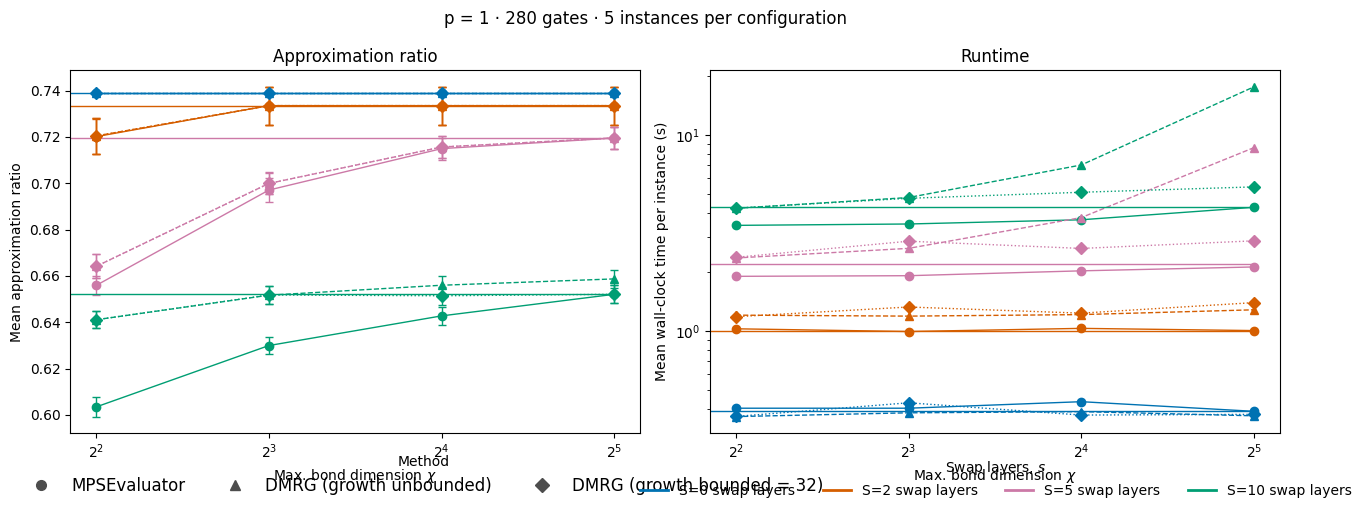

In [14]:
bond_dimensions = [4, 8, 16, 32]

gates_per_block = 280

methods = {
    "MPSEvaluator": lambda chi: MPSEvaluator(
        bond_dim_circuit=chi, threshold_circuit=1e-14, use_swap_strategy=True
    ),
    "DMRG (growth unbounded)": lambda chi: DMRGStyleEvaluator(
        compress_max_bond=chi,
        gates_per_block=gates_per_block,
        method="fit-zipup",
    ),
    "DMRG (growth bounded = 32)": lambda chi: DMRGStyleEvaluator(
        compress_max_bond=chi,
        growth_max_bond=32,
        gates_per_block=gates_per_block,
        method="fit-zipup",
    ),
}

mps_baseline = MPSEvaluator(bond_dim_circuit=32, threshold_circuit=1e-14, use_swap_strategy=True)

swap_colors = {
    0: "#0072B2",
    2: "#D55E00",
    5: "#CC79A7",
    10: "#009E73",
}
method_styles = {
    "MPSEvaluator": dict(marker="o", linestyle="-"),
    "DMRG (growth unbounded)": dict(marker="^", linestyle="--"),
    "DMRG (growth bounded = 32)": dict(marker="D", linestyle=":"),
}
for depth in depths:
    results = {name: {k: {"mean": [], "std": []} for k in swap_layer_counts} for name in methods}
    results_baseline = {k: {"mean": [], "std": []} for k in swap_layer_counts}
    runtimes_baseline = {k: [] for k in swap_layer_counts}

    runtimes = {name: {k: [] for k in swap_layer_counts} for name in methods}

    for chi in bond_dimensions:
        for name, factory in methods.items():
            for k in swap_layer_counts:
                start = time.time()
                ratios = [
                    approximation_ratio(
                        factory(chi).evaluate(cost_op, params), s_weights, m_min, m_max
                    )
                    for cost_op, params, s_weights, m_min, m_max in zip(
                        groups[depth][k]["cost_ops"],
                        groups[depth][k]["opt_angles"],
                        groups[depth][k]["sums_of_weights"],
                        groups[depth][k]["min_cuts"],
                        groups[depth][k]["max_cuts"],
                    )
                ]
                runtimes[name][k].append((time.time() - start) / n_instances_per_group)
                results[name][k]["mean"].append(np.mean(ratios))
                results[name][k]["std"].append(np.std(ratios))
            print(f"depth={depth}, chi={chi}, {name}: done")

    for k in swap_layer_counts:
        start = time.time()
        ratios = [
            approximation_ratio(mps_baseline.evaluate(cost_op, params), s_weights, m_min, m_max)
            for cost_op, params, s_weights, m_min, m_max in zip(
                groups[depth][k]["cost_ops"],
                groups[depth][k]["opt_angles"],
                groups[depth][k]["sums_of_weights"],
                groups[depth][k]["min_cuts"],
                groups[depth][k]["max_cuts"],
            )
        ]
        runtimes_baseline[k].append((time.time() - start) / n_instances_per_group)
        results_baseline[k]["mean"].append(np.mean(ratios))
        results_baseline[k]["std"].append(np.std(ratios))

    fig, (ax_ratio, ax_time) = plt.subplots(1, 2, figsize=(13, 5))

    for name in methods:
        for k in swap_layer_counts:
            ax_ratio.errorbar(
                bond_dimensions,
                results[name][k]["mean"],
                yerr=results[name][k]["std"],
                fmt=method_styles[name]["marker"] + "-",
                linestyle=method_styles[name]["linestyle"],
                color=swap_colors[k],
                capsize=3,
                markersize=6,
                linewidth=1,
            )
    for k in swap_layer_counts:
        ax_ratio.hlines(
            results_baseline[k]["mean"],
            xmin=0,
            xmax=bond_dimensions[-1],
            color=swap_colors[k],
            linewidth=1,
        )
    ax_ratio.set_xlabel(r"Max. bond dimension $\chi$")
    ax_ratio.set_ylabel("Mean approximation ratio")
    ax_ratio.set_title("Approximation ratio")
    ax_ratio.set_xscale("log", base=2)
    for name in methods:
        for k in swap_layer_counts:
            ax_time.plot(
                bond_dimensions,
                runtimes[name][k],
                method_styles[name]["marker"] + "-",
                linestyle=method_styles[name]["linestyle"],
                color=swap_colors[k],
                markersize=6,
                linewidth=1,
            )
    for k in swap_layer_counts:
        ax_time.hlines(
            runtimes_baseline[k],
            xmin=0,
            xmax=bond_dimensions[-1],
            color=swap_colors[k],
            linewidth=1,
        )
    ax_time.set_xlabel(r"Max. bond dimension $\chi$")
    ax_time.set_ylabel("Mean wall-clock time per instance (s)")
    ax_time.set_title("Runtime")
    ax_time.set_yscale("log")
    ax_time.set_xscale("log", base=2)

    # Two separate legends: color = swap-layer count, marker shape = method.
    from matplotlib.lines import Line2D

    color_handles = [
        Line2D([0], [0], color=swap_colors[k], lw=2, label=f"S={k} swap layers")
        for k in swap_layer_counts
    ]
    marker_handles = [
        Line2D(
            [0],
            [0],
            color="0.3",
            marker=method_styles[name]["marker"],
            linestyle="",
            markersize=7,
            label=name,
        )
        for name in methods
    ]
    fig.legend(
        handles=marker_handles,
        title="Method",
        loc="lower center",
        bbox_to_anchor=(0.33, -0.02),
        ncol=3,
        frameon=False,
        fontsize=12,
    )

    fig.legend(
        handles=color_handles,
        title="Swap layers, $s$",
        loc="lower center",
        bbox_to_anchor=(0.77, -0.02),
        ncol=4,
        frameon=False,
    )

    fig.subplots_adjust(bottom=0.22)

    fig.suptitle(
        f"p = {depth} · {gates_per_block} gates · {n_instances_per_group} instances per configuration"
    )
    fig.tight_layout()

### Lessons learned from this benchmark
From the experiments run for 100-node line-based instances:
- The number of gates per block matters a lot. For a low number, for example 1 to 20, there is almost no gain over the MPSEvaluator.
- At a higher number of gates per block, for example 50, there is a noticeable accuracy gain.
- This gain in accuracy is especially noticeable at low final bond dimension.
- The real gain comes from the fact that the resulting state has lower bond dimension, but reaches better energy values than the vanilla MPS at the same low bond dimension. This might be especially useful if this state needs to be used for something later, like drawing samples.

## Effect of block size

Study the effect of block size in DMRG by sweeping over different block sizes at fixed bond dimension and for an individual line-based instance

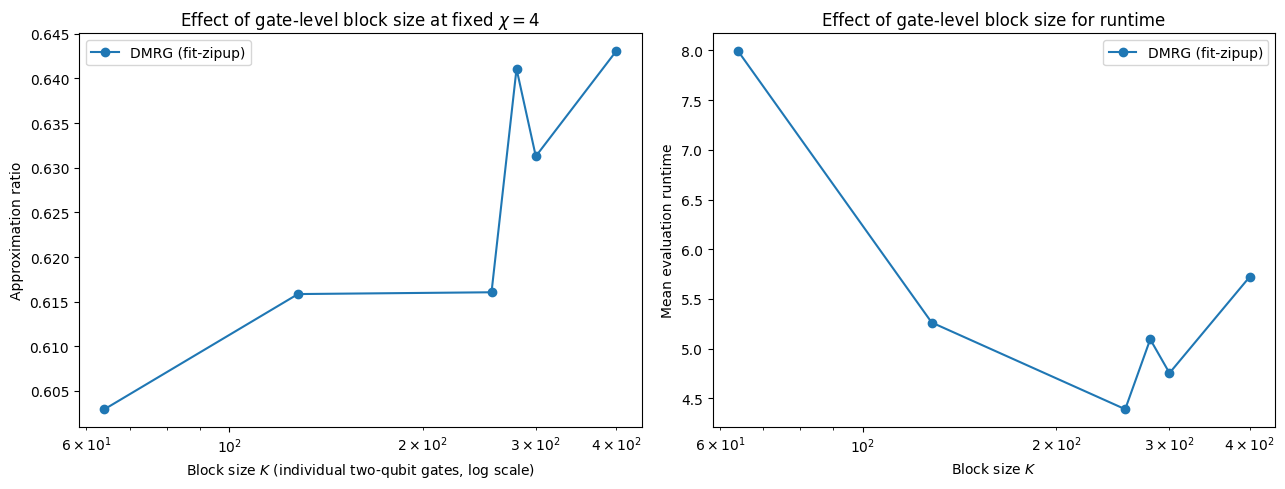

In [15]:
chi_fixed = 4
gate_block_sizes = [
    # 16,
    # 32,
    64,
    128,
    256,
    280,
    300,
    400,
]

cost_ops = groups[depth][10]["cost_ops"]
params = groups[depth][10]["opt_angles"]
s_weights = groups[depth][10]["sums_of_weights"]
m_maxs = groups[depth][10]["max_cuts"]
m_mins = groups[depth][10]["min_cuts"]

approx_ratio_k = {"DMRG (fit-zipup)": []}
runtimes = []
for k in gate_block_sizes:
    ratios = []
    start = time.time()
    for cost_op, params_opt, s_weight, m_min, m_max in zip(
        cost_ops, params, s_weights, m_mins, m_maxs
    ):
        e_fit = DMRGStyleEvaluator(
            chi_fixed, gates_per_block=k, method="fit-zipup", swap_strategy=None
        ).evaluate(cost_op, params_opt)
        ratios.append(approximation_ratio(e_fit, s_weight, m_min, m_max))
    approx_ratio_k["DMRG (fit-zipup)"].append(np.mean(ratios))
    runtimes.append((time.time() - start) / n_instances_per_group)
fig, (ax, ax_time) = plt.subplots(1, 2, figsize=(13, 5))
ax.plot(gate_block_sizes, approx_ratio_k["DMRG (fit-zipup)"], "o-", label="DMRG (fit-zipup)")
ax.set_xscale("log")
ax.set_xlabel(r"Block size $K$ (individual two-qubit gates, log scale)")
ax.set_ylabel("Approximation ratio")
ax.set_title(rf"Effect of gate-level block size at fixed $\chi={chi_fixed}$")
ax.legend()
ax_time.plot(gate_block_sizes, runtimes, "o-", label="DMRG (fit-zipup)")
ax_time.set_xscale("log")
ax_time.set_xlabel(r"Block size $K$")
ax_time.set_ylabel("Mean evaluation runtime")
ax_time.set_title("Effect of gate-level block size for runtime")
ax_time.legend()
fig.tight_layout()

### Lessons learned
- There is an optimal value for the number of gates in each block. 
- In the first range of values, the cost of performing the fitting to an MPS of fixed $\chi$ every $K$ gates dominates, therefore the reduction in time when increasing $K$.